## Collect Raw Data and Store in S3

Pull the raw Diabetes 130-US Hospitals dataset directly from the UCI Machine Learning Repository and land it in our S3 data lake under a `raw/` prefix, untouched, before any cleaning or transformation happens.

In [5]:
import boto3

sts = boto3.client("sts")
account_id = sts.get_caller_identity()["Account"]
region = boto3.session.Session().region_name

bucket = f"sagemaker-{region}-{account_id}"  # same naming SageMaker's SDK would've used anyway

s3 = boto3.client("s3")
existing = [b["Name"] for b in s3.list_buckets()["Buckets"]]
if bucket not in existing:
    if region == "us-east-1":
        s3.create_bucket(Bucket=bucket)
    else:
        s3.create_bucket(Bucket=bucket, CreateBucketConfiguration={"LocationConstraint": region})

prefix = "raw/diabetes-130-hospitals"
s3.upload_file("diabetic_data_raw.csv", bucket, f"{prefix}/diabetic_data_raw.csv")
print(f"Uploaded to s3://{bucket}/{prefix}/diabetic_data_raw.csv")

Uploaded to s3://sagemaker-us-east-1-382172466789/raw/diabetes-130-hospitals/diabetic_data_raw.csv


## Catalog the Data with AWS Glue

Set up a Glue database and crawler pointed at the raw S3 data. The crawler scans the CSV, infers its schema, and registers it as a table in the Glue Data Catalog, which is what makes it queryable through Athena.

In [6]:
import boto3

glue = boto3.client("glue")
database_name = "aai540_group5_readmission"

# creates the "namespace" Athena/Glue will organize your tables under
glue.create_database(
    DatabaseInput={
        "Name": database_name,
        "Description": "Data for the diabetic readmission prediction project"
    }
)
print(f"Created database: {database_name}")

crawler_name = "diabetes-130-raw-crawler"

glue.create_crawler(
    Name=crawler_name,
    Role="LabRole",
    DatabaseName=database_name,
    Targets={"S3Targets": [{"Path": f"s3://{bucket}/raw/diabetes-130-hospitals/"}]},
)

glue.start_crawler(Name=crawler_name)
print("Crawler started, takes a couple minutes to finish")

Created database: aai540_group5_readmission
Crawler started, takes a couple minutes to finish


In [8]:
print(glue.get_crawler(Name=crawler_name)["Crawler"]["State"])

READY


## Verify Athena Cataloging

Confirm the Glue Crawler successfully created a queryable table from the raw diabetic encounter data, then run a test query through Athena to make sure the table is actually usable, not just present in the catalog.

In [9]:
# confirm the crawler created a table
tables = glue.get_tables(DatabaseName=database_name)["TableList"]
table_name = tables[0]["Name"]
print(f"Table created: {table_name}")

# run a test query through Athena
athena = boto3.client("athena")
output_location = f"s3://{bucket}/athena-results/"

response = athena.start_query_execution(
    QueryString=f"SELECT * FROM {database_name}.{table_name} LIMIT 10",
    QueryExecutionContext={"Database": database_name},
    ResultConfiguration={"OutputLocation": output_location},
)
query_execution_id = response["QueryExecutionId"]
print(f"Query started: {query_execution_id}")

Table created: diabetes_130_hospitals
Query started: ded3a64d-103b-463f-82b1-8cdcad38c24d


In [10]:
import time

while True:
    status = athena.get_query_execution(QueryExecutionId=query_execution_id)["QueryExecution"]["Status"]["State"]
    if status in ["SUCCEEDED", "FAILED", "CANCELLED"]:
        break
    time.sleep(2)

print(status)

if status == "SUCCEEDED":
    results = athena.get_query_results(QueryExecutionId=query_execution_id)
    for row in results["ResultSet"]["Rows"][:5]:
        print([col.get("VarCharValue") for col in row["Data"]])

SUCCEEDED
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'a1cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesmed', 'readmitted']
['Caucasian', 'Female', '[0-10)', '', '6', '25', '1', '1', '', 'Pediatrics-Endocrinology', '41', '0', '1', '0', '0', '0', '250.83', '', '', '1', '', '', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'N

## Exploratory Data Analysis

Load the raw data from S3 and get a first look at its shape, structure, and data quality before deciding how to clean and engineer features.

In [11]:
import pandas as pd

df = pd.read_csv(f"s3://{bucket}/raw/diabetes-130-hospitals/diabetic_data_raw.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 48)


/tmp/ipykernel_827/3628798455.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"s3://{bucket}/raw/diabetes-130-hospitals/diabetic_data_raw.csv")


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
missing_pct = df.isna().sum().sort_values(ascending=False) / len(df) * 100
print(missing_pct[missing_pct > 0])

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [14]:
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True) * 100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


In [15]:
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30d'].value_counts())

readmitted_30d
0    90409
1    11357
Name: count, dtype: int64


### Compare Hypothesized Features Against the Target

Check whether prior utilization, length of stay, and medication count actually differ between patients who were and weren't readmitted within 30 days, confirming (or challenging) the features flagged in the design doc.

In [16]:
features_to_check = ['number_inpatient', 'number_emergency', 'number_outpatient',
                      'time_in_hospital', 'num_medications', 'number_diagnoses']

print(df.groupby('readmitted_30d')[features_to_check].mean())

                number_inpatient  number_emergency  number_outpatient  \
readmitted_30d                                                          
0                       0.561648          0.177803           0.360871   
1                       1.224003          0.357313           0.436911   

                time_in_hospital  num_medications  number_diagnoses  
readmitted_30d                                                       
0                       4.349224        15.911137          7.388667  
1                       4.768249        16.903143          7.692789  


In [17]:
for col in ['race', 'gender', 'age']:
    print(df.groupby(col)['readmitted_30d'].mean().sort_values(ascending=False))
    print()

race
Caucasian          0.112906
AfricanAmerican    0.112181
Hispanic           0.104075
Asian              0.101404
Other              0.096282
Name: readmitted_30d, dtype: float64

gender
Female             0.112452
Male               0.110615
Unknown/Invalid    0.000000
Name: readmitted_30d, dtype: float64

age
[20-30)     0.142426
[80-90)     0.120835
[70-80)     0.117731
[30-40)     0.112318
[60-70)     0.111284
[90-100)    0.110992
[40-50)     0.106040
[50-60)     0.096662
[10-20)     0.057887
[0-10)      0.018634
Name: readmitted_30d, dtype: float64



In [18]:
print(df['gender'].value_counts())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


### Visualize: Readmission Rate by Age Group

A quick bar chart of the age pattern we just found, useful for the final report and video demo since the [20-30) spike is easy to miss in a table but jumps out visually.

[09/25/26 21:42:08] INFO     generated new fontManager                                         ]8;id=9623147;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=9623148;file:///opt/conda/lib/python3.12/site-packages/matplotlib/font_manager.py#1639\1639]8;;\

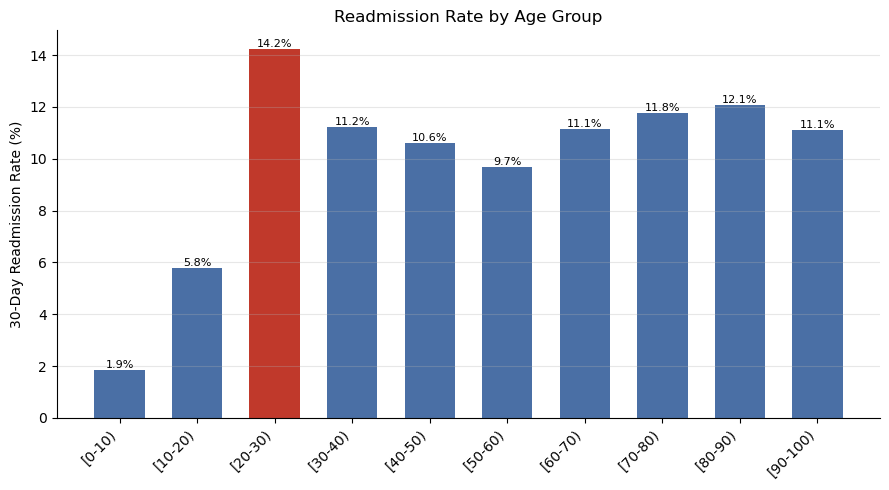

In [19]:
import matplotlib.pyplot as plt

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
rates = df.groupby('age')['readmitted_30d'].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if age == '[20-30)' else '#4a6fa5' for age in age_order]
bars = ax.bar(age_order, rates, color=colors, width=0.65)

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('Readmission Rate by Age Group')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

for bar, rate in zip(bars, rates):
    ax.annotate(f'{rate:.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('readmission_by_age.png', dpi=150)
plt.show()